# Model evaluation #
Modified from 実践Data Scienceシリーズ Pythonではじめる時系列分析入門

ISBN:4065369827


In [ ]:
!pip install numpy==1.26.4
!pip install pmdarima


In [ ]:
# Computation library
import numpy as np
import pandas as pd
from scipy import stats

# Graph
from matplotlib import pyplot as plt
import seaborn as sns
sns.set()

# Time series model
import statsmodels.api as sm
import statsmodels.tsa.api as tsa
import statsmodels.formula.api as smf
import pmdarima as pm


In [ ]:
# initial setting
np.set_printoptions(linewidth=60)
pd.set_option('display.width', 80)

from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 8, 4

#plot acf and pacf
def plotACF_PACFsample(dataset, num_lag, title):
  fig,ax = plt.subplots(1,2,figsize=(16,4), tight_layout=True)
  _ = sm.graphics.tsa.plot_acf(dataset, lags=num_lag, title='Sample ACF', ax=ax[0])
  _ = sm.graphics.tsa.plot_pacf(dataset, lags=num_lag, title='Sample PACF', ax=ax[1])
  fig.suptitle(title, fontsize=16)

In [ ]:
#load data
dta_raw = pd.read_json('Test_data.json')
num_sample = len(dta_raw)
my_timeframe = pd.date_range(start='1/27/2026', periods=num_sample, freq='D')
display(dta_raw.head(10))




,ma_1,ma_2,ma_4,ar_1,ar_2,ar_3,ar_4,arma_1_1,arma_2_2,arma_3_1,arima_3_1_0,arima_0_1_2,arima_0_2_1,arima_3_1_1,arima_1_2_1,sarima_1_0_1_0_1_0_6,sarima_1_1_1_0_1_0_6,sarima_0_0_1_0_2_0_5
2026-01-22,-5.320245,-0.209240,-0.018840,0.801110,-0.474598,0.000760,-0.482651,-1.630329,0.788762,1.906785,0.000760,-0.209240,-5.320245,1.906785,-1.630329,-1.630329,-1.630329,-5.320245
2026-01-23,-6.941266,0.325296,-0.945214,1.850113,-0.015073,-1.138848,-1.976469,-2.888082,-0.344223,1.696741,-1.138089,0.116056,-17.581757,3.603526,-6.148740,-2.888082,-4.518411,-6.941266
2026-01-24,-0.696844,-0.985301,-0.149420,0.139264,-0.032850,-0.334077,0.245101,-1.000064,1.751022,1.115828,-1.472166,-0.869245,-30.540112,4.719354,-11.667215,-1.000064,-5.518475,-0.696844
2026-01-25,2.181002,-1.607183,-1.135898,-1.312399,0.024893,-1.060009,-0.710527,-1.087399,-1.911612,4.367383,-2.532175,-2.476428,-41.317466,9.086737,-18.273090,-1.087399,-6.605875,2.181002
2026-01-26,-2.024862,-1.074732,-0.584504,-2.249788,0.736185,-1.679779,-1.029522,-1.581673,1.712212,4.421467,-4.211954,-3.551160,-54.119681,13.508204,-26.460637,-1.581673,-8.187547,-2.024862
2026-01-27,3.886576,-0.246283,0.719000,-1.554062,-1.527883,2.588999,0.779183,2.915894,-0.778701,5.688946,-1.622954,-3.797442,-63.035320,19.197149,-31.732291,2.915894,-5.271654,-6.753915
2026-01-28,3.985619,-1.388156,1.532655,-0.059495,-0.094514,-0.590086,-1.642046,2.496549,-1.143352,3.055130,-2.213040,-5.185598,-67.965341,22.252279,-34.507395,0.866220,-4.405433,-9.896913
2026-01-29,2.516224,1.735961,1.235230,-0.508188,2.183692,-1.307776,-1.623729,-0.029704,0.099414,3.369958,-3.520817,-3.449637,-70.379137,25.622237,-37.312204,-2.917787,-7.323220,1.122535
2026-01-30,-1.541970,0.259540,0.266636,-0.106056,-1.150243,0.083243,-1.319713,-1.683255,0.788629,2.585602,-3.437573,-3.190097,-74.334903,28.207839,-41.800268,-2.683320,-10.006540,2.820035
2026-01-31,-0.477389,-0.519271,1.377564,-0.549777,0.692712,1.296863,-1.153812,-2.080846,-0.072427,3.443908,-2.140710,-3.709368,-78.768059,31.651747,-48.369179,-3.168246,-13.174785,-4.527113


## Assign the training and testing data.

,data
time,
2026-01-27,-0.209240
2026-01-28,0.325296
2026-01-29,-0.985301
2026-01-30,-1.607183
2026-01-31,-1.074732


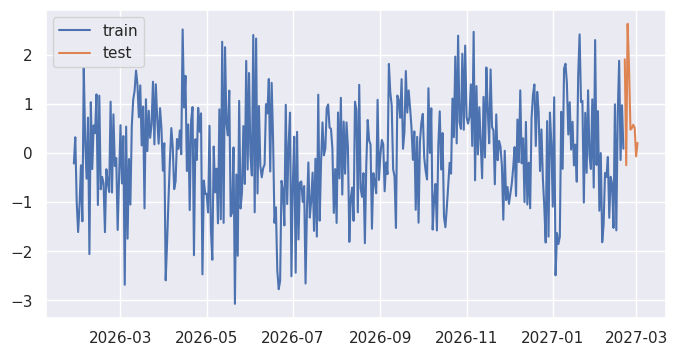

In [ ]:
my_df = pd.DataFrame({
    'time' : my_timeframe,
    'data' : dta_raw['ma_2']},  # put our data here.
)
my_df = my_df.set_index('time')
my_df.index.freq = 'D'
display(my_df.head())

# Split the last 10 data for testing
dta_train = my_df[ :num_sample-10]
dta_test = my_df[-10:]
plt.plot(dta_train.data, label='train')
plt.plot(dta_test.data, label='test')
plt.legend()


## Validate the model from the auto_arima in pmdarima

In [ ]:
autoArima_best = pm.arima.auto_arima(
    y = my_df['data'],                  # data
    test='kpss',              # KPSS test to find d
    seasonal_test='ocsb',     # OCSB test to find D
    criterion='AIC',          # AIC to choose model
    #m=12,                     # M=12
    max_p=5, max_q=2, max_P=0, max_Q=0,              # max order
    start_p=0, start_q=0, start_Q=0, start_P=0,      # initial order
    stepwise=False,          # Use stepwise or not (quicker if we use)
    n_jobs=-1,               # Use every available core
    maxiter=5000,            # Maximum iteration for fitting
    with_intercept=False,    # Model without interception
    solver='nm'              # Solver type)
)

From the summary, how can we know that we get the best model?

In [ ]:
print(autoArima_best.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  400
Model:               SARIMAX(0, 0, 2)   Log Likelihood                -551.461
Date:                Tue, 27 Jan 2026   AIC                           1108.922
Time:                        01:12:27   BIC                           1120.896
Sample:                    01-27-2026   HQIC                          1113.664
                         - 03-02-2027                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.0160      0.043      0.371      0.711      -0.068       0.100
ma.L2          0.5495      0.045     12.282      0.000       0.462       0.637
sigma2         0.9209      0.069     13.360      0.0

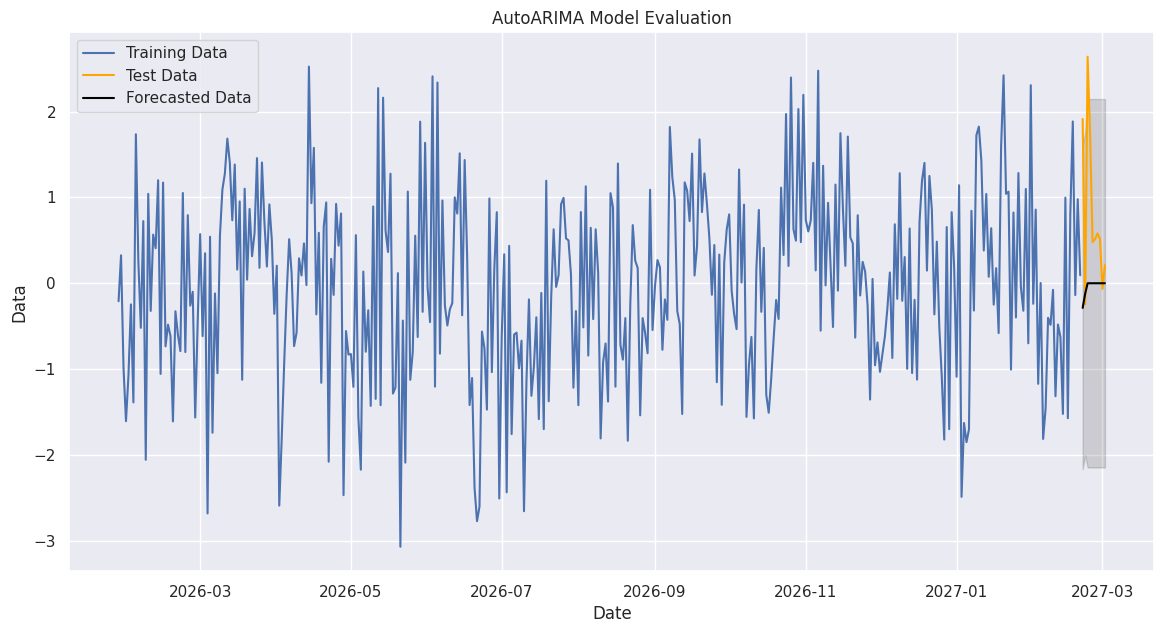

In [ ]:
forecast, conf_int = autoArima_best.predict(n_periods=10, return_conf_int=True)

# Create a plot to compare the forecast with the actual test data
plt.figure(figsize=(14,7))
plt.plot(dta_train['data'], label='Training Data')
plt.plot(dta_test['data'], label='Test Data', color='orange')
plt.plot(dta_test.index,forecast, label='Forecasted Data', color='black')
plt.fill_between(dta_test.index,
                 conf_int[:, 0], conf_int[:, 1],
                 alpha = 0.15, color='k')
plt.title('AutoARIMA Model Evaluation')
plt.xlabel('Date')
plt.ylabel('Data')
plt.legend()
plt.show()


For simplicity, let consider the ARMA(p,q) model.
$$y_t = \sum_{i=1}^{p} \phi_i y_{t-i} + w_t + \sum_{i=1}^{q} \theta_i w_{t-i}$$
The perfect forecast is  
$$\hat{y}_t = \sum_{i=1}^{p} \phi_i y_{t-i} + \sum_{i=1}^{q} \theta_i w_{t-i}.$$
Note that we don't know $w_t$ in advance so we can only make the guess with its mean. Consequenctly, the residual of our perfect forecast will be
$$y_t-\hat{y}_t = w_t.$$
Thus, we can test whether we get the perfect forecast by checking whether the residual has the same statistics as $w_t$ or not. In this case, it is white Gaussian noise.


### Evaluation (1): use the provided diagnostic tools
From the diagnostics, we have four graphs.
* Standardized residual : should look like a white noise
* Histogram plus estimated density : the KDE (Kernel density estimation) should be similar to N(0,1).
* Normal Q-Q : the polot should follows the straight line
* Correlogram : ACF of our estimation should be about zero for the lag > 0.

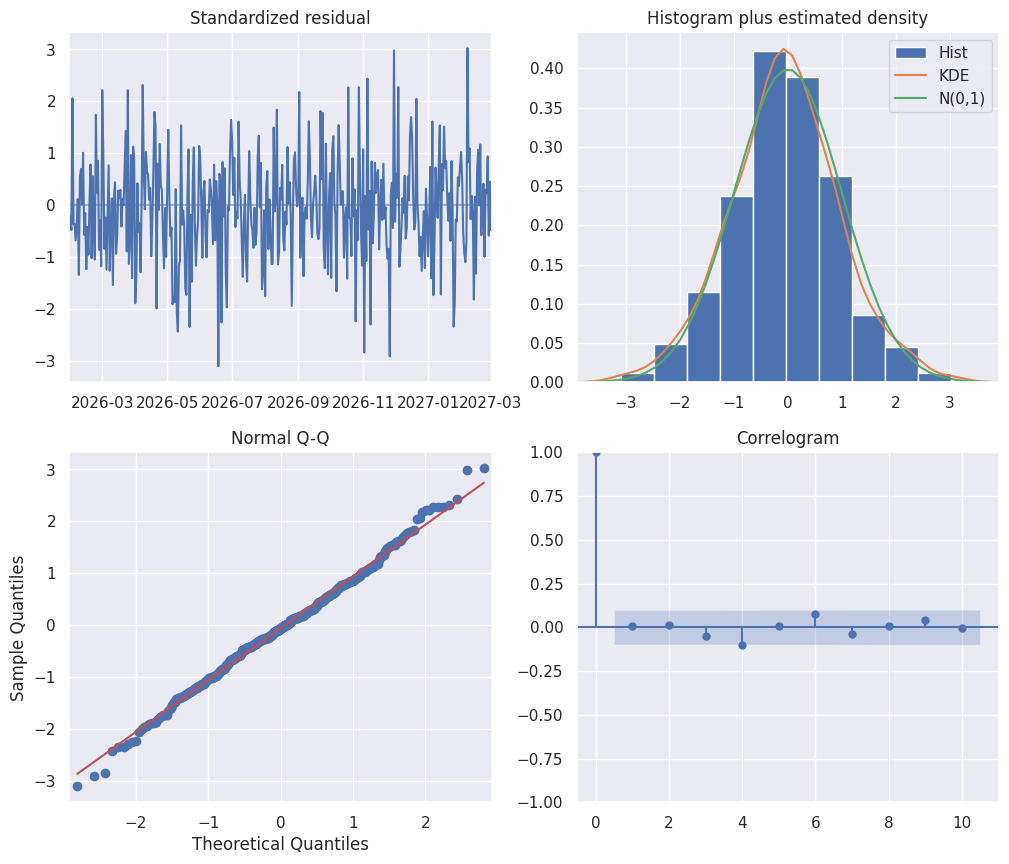

In [ ]:
autoArima_best.plot_diagnostics(figsize=(12,10));

###Evaluation (2): check ACF and PACF of the residual. Residual at different time should not have any correlation.  

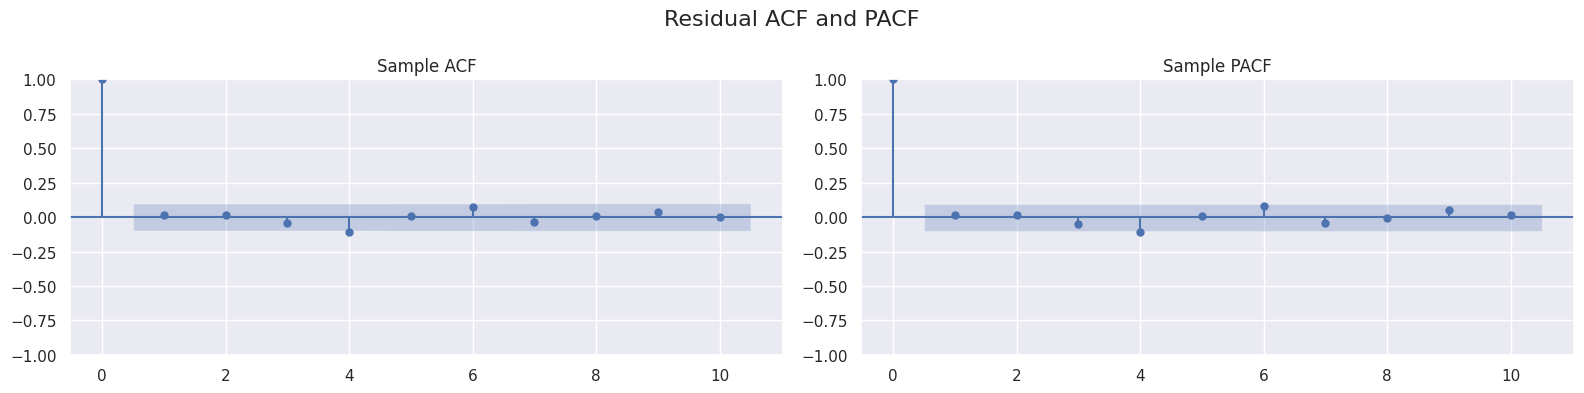

In [ ]:
resid = autoArima_best.resid()
plotACF_PACFsample(resid, 10, 'Residual ACF and PACF')

### Evaluation (3): Ljung-Box test
This test should be used to show that the residual is uncorrelated up to lag $K$, i.e. $\rho(1) = \rho(2) = \cdots = \rho(K) = 0$. However, instead of setting the desired property as $H_1$, it is set as $H_0$.

- $H_0$: $\rho(1) = \rho(2) = \cdots = \rho(K) = 0$
- $H_1$: $\exists \rho(k) \ne 0 \text{ for } k = 0, 1, \cdots, K$

If the P-value from this test is less than 0.05, it indicated that the residual is not random. However, P-value larger than 0.05 cannot be used to intepret that the $H_0$ is correct. In practice setting $K$ too high leads to low accuracy.

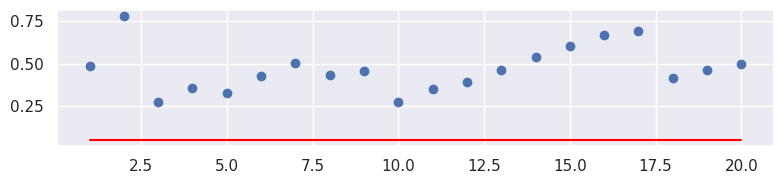

In [ ]:
# All dots should be above the red line.
num_lag = 20
Ljung_box = autoArima_best.arima_res_.test_serial_correlation(method = 'ljungbox', lags = num_lag)
fig, ax = plt.subplots(figsize= (8,2), tight_layout=True)
ax.scatter(np.arange(1,num_lag+1), Ljung_box[0][1])
#plot 0.05 line
ax.plot(np.arange(1,num_lag+1), np.tile(0.05,num_lag), color='red')


###Evaluation (4): Mean squared error of the test data.

In [ ]:
from sklearn.metrics import mean_squared_error
actual = dta_test['data']
forecast = autoArima_best.predict(n_periods=len(dta_test))
RMSE = mean_squared_error(actual, forecast)**0.5
display(RMSE)

1.2631681824364982

##Validate the model from tsa.SARIMAX

SARIMAX can be used to find the SARIMA model of the given (p,d,q)(P,D,Q,S) so we have to make an education guess and check it out in the same manner as in auto_arima. The result may be a bit different but overall, we get the similar model.

In [ ]:
MyModel =  tsa.SARIMAX(dta_train['data'], order=(0,0,3), # ARIMA (p,d,q)
                       seasonal_order=[0,0,0,0], # Seasonal (P,D,Q,S)
                       trend='c',
                       missing = 'none' # 'none' (no missing data), 'drop' the NAN, 'raise' error
                       ).fit()
MyModel.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                   data   No. Observations:                  390
Model:               SARIMAX(0, 0, 3)   Log Likelihood                -535.334
Date:                Tue, 27 Jan 2026   AIC                           1080.668
Time:                        01:41:03   BIC                           1100.499
Sample:                    01-27-2026   HQIC                          1088.529
                         - 02-20-2027                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0319      0.080     -0.396      0.692      -0.190       0.126
ma.L1          0.0496      0.052      0.950      0.342      -0.053       0.152
ma.L2          0.5565      0.046     12.074      0.000       0.466       0.647
ma.L3          0.0425      0.049      0.870      0.385      -0.053       0.138
sigma2         0.9098      0.069     13.126      0.000       0.774       1.046
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.49
Prob(Q):                              0.98   Prob(JB):                         0.47
Heteroskedasticity (H):               0.78   Skew:                            -0.11
Prob(H) (two-sided):                  0.16   Kurtosis:                         2.79
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

###Forecast result

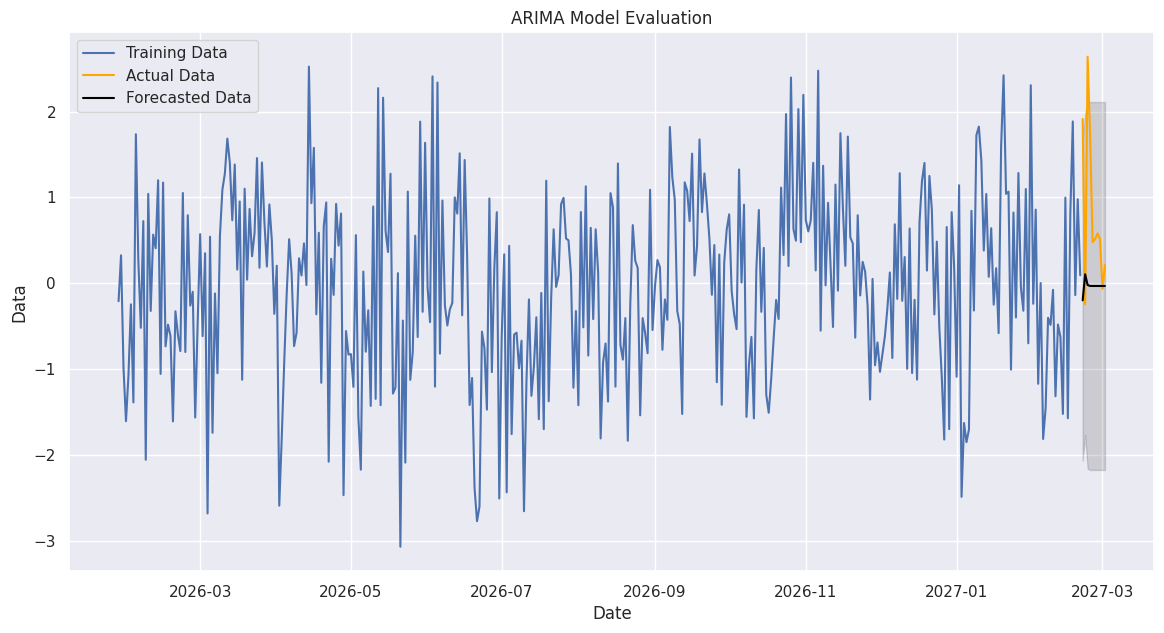

In [ ]:
nforecast = len(dta_test['data'])
ndata = len(dta_train['data'])

test_forecast = MyModel.get_prediction(start = ndata, end = ndata + nforecast -1)
test_forecast_series = pd.Series(test_forecast.predicted_mean)

# Create a plot to compare the forecast with the actual test data
plt.figure(figsize=(14,7))
plt.plot(dta_train['data'], label='Training Data')
plt.plot(dta_test['data'], label='Actual Data', color='orange')
plt.plot(test_forecast_series, label='Forecasted Data', color='black')
plt.fill_between(dta_test.index,
                 test_forecast.conf_int().iloc[:, 0],
                 test_forecast.conf_int().iloc[:, 1],
                 color='k', alpha=.15)
plt.title('ARIMA Model Evaluation')
plt.xlabel('Date')
plt.ylabel('Data')
plt.legend()
plt.show()

### Evaluate (1): use the provided diagnostic tools

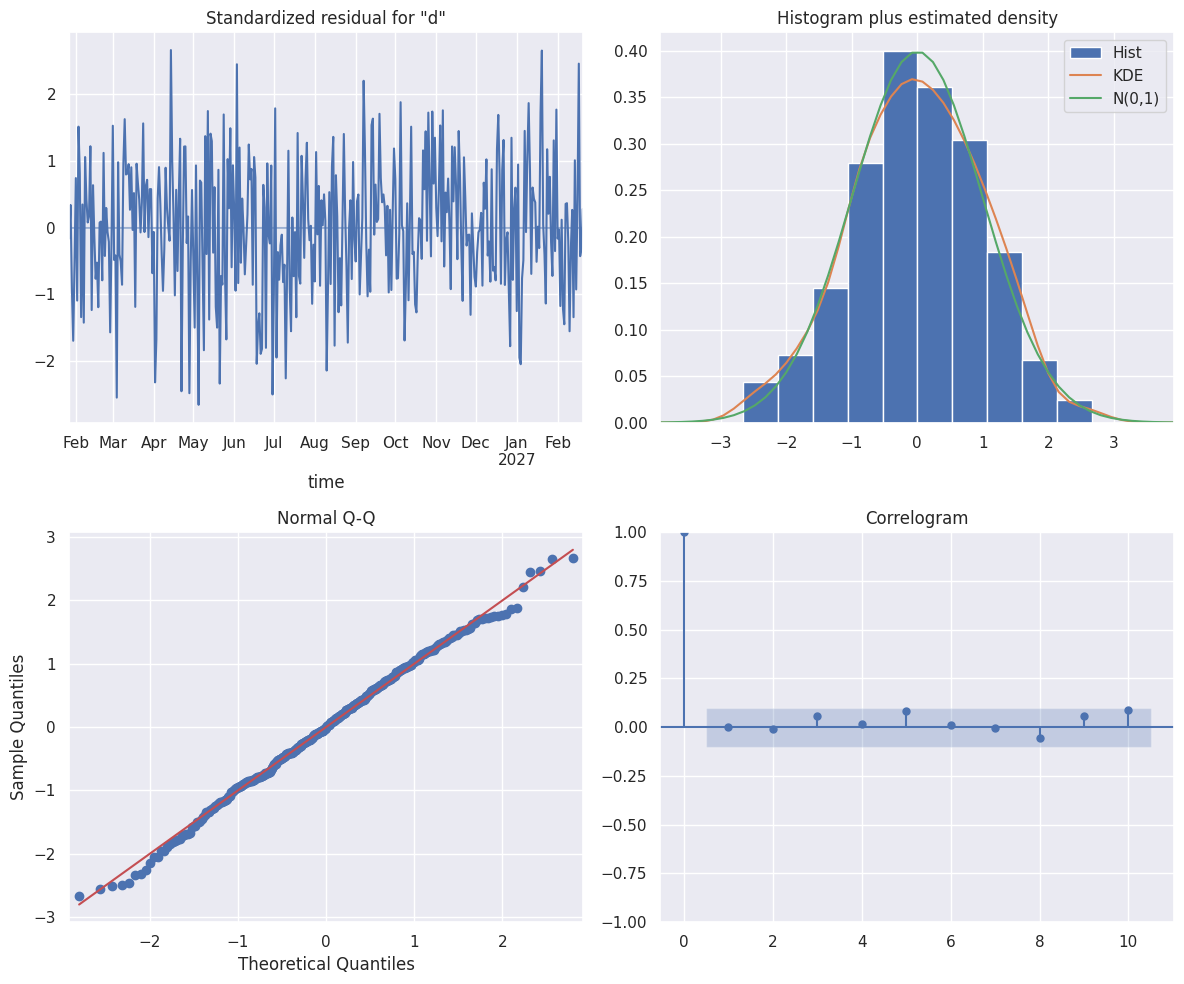

In [ ]:
fig = MyModel.plot_diagnostics(figsize=(12, 10))
fig.tight_layout()
plt.show()

###Evaluate (2): check ACF and PACF

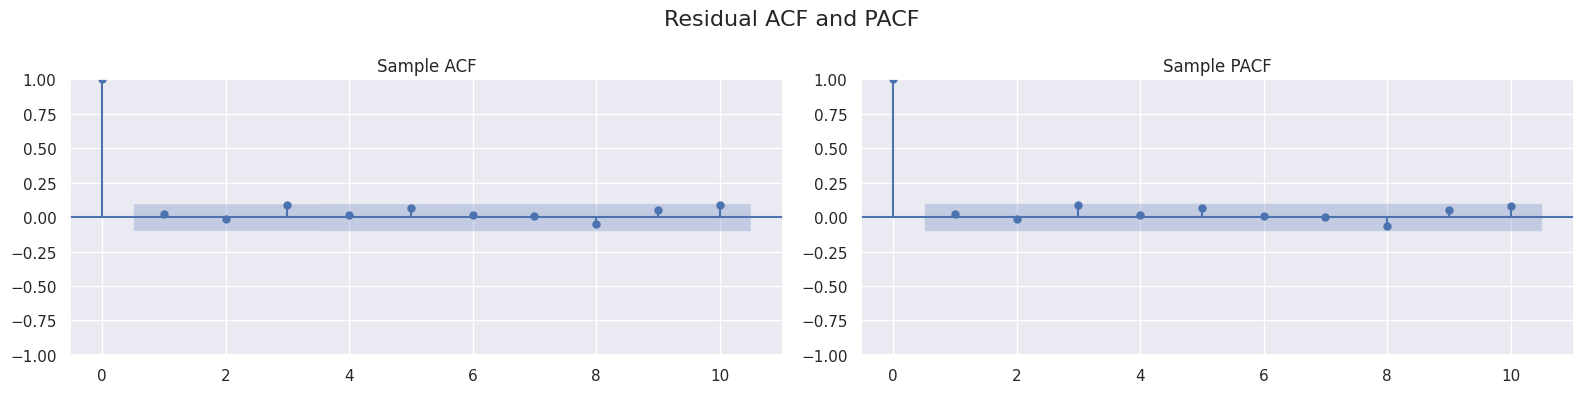

In [ ]:
resid = MyModel.resid
plotACF_PACFsample(resid, 10, 'Residual ACF and PACF')

###Evaluation (3): Ljung-Box test

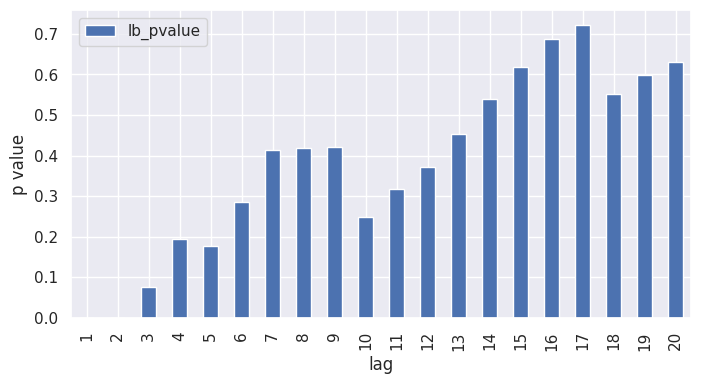

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

num_lag = 20
Ljung_box = acorr_ljungbox(resid,
                           model_df = 2,  #degree of freedom = p+q
                           lags = num_lag)
Ljung_box.plot(y='lb_pvalue', kind='bar', xlabel= 'lag', ylabel='p value')
plt.show()

### Evaluation (4): MSE of the test data

In [ ]:
from sklearn.metrics import mean_squared_error
actual = dta_test['data']
test_forecast = MyModel.get_forecast(steps = len(dta_test))
forecast = pd.Series(test_forecast.predicted_mean)
RMSE = mean_squared_error(actual, forecast)**0.5
display(RMSE)

1.270249385590557